In [1]:
#@title 1. Setup — pinned project source
import sys, subprocess, os, json
from pathlib import Path
REPO = Path("/content/ML-IoT-based-FYP")
COMMIT = "27bbce9e2712cb9fafe77b9ec19a40ae8d19ab55"
if not (REPO / ".git").exists():
    subprocess.run(["git","clone","https://github.com/Melingasuk/ML-IoT-based-FYP.git",str(REPO)],check=True)
subprocess.run(["git","-C",str(REPO),"fetch","origin"],check=True)
subprocess.run(["git","-C",str(REPO),"checkout",COMMIT],check=True)
subprocess.run([sys.executable,"-m","pip","install","-q","numpy==2.1.3","pandas==2.2.3","matplotlib","pytest"],check=True)
os.chdir(REPO/"training")
sys.path.insert(0,str(REPO/"training/src"))
os.environ["PYTHONPATH"]=str(REPO/"training/src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
print("Pinned source:",COMMIT)
print("Synthetic prototype only; not field validation. No ESP32 firmware is changed.")

Pinned source: 27bbce9e2712cb9fafe77b9ec19a40ae8d19ab55
Synthetic prototype only; not field validation. No ESP32 firmware is changed.


In [2]:
#@title 2. Synthetic generation — 1,000 samples, four crops
from soil_ml.synthetic import save_synthetic_dataset
DATA = Path("data/synthetic/soil_synthetic_prototype.csv")
df = save_synthetic_dataset(DATA, rows_per_crop=250, seed=42)
print("Generated:", len(df), "synthetic rows; seed=42")
print(df.label.value_counts().to_string())
print("Inputs:", list(df.columns))
assert len(df)==1000 and df.label.nunique()==4
assert not df.duplicated().any()

Generated: 1000 synthetic rows; seed=42
label
kidneybeans    250
banana         250
cabbage        250
maize          250
Inputs: ['SM', 'ST7in1', 'pH', 'N', 'P', 'K', 'EC', 'STDS18B20', 'SMCap', 'label']


In [3]:
#@title 3. Stratified splitting — 70% training, 15% validation, 15% test
from soil_ml.train import load_training_data, stratified_split, train_random_forest, evaluate_model, model_size_summary
from soil_ml import MODEL_FEATURES
x,y = load_training_data(DATA)
x_train,x_val,x_test,y_train,y_val,y_test = stratified_split(x,y,seed=42)
assert (len(x_train),len(x_val),len(x_test))==(700,150,150)
sets=[set(map(tuple,a.to_numpy())) for a in (x_train,x_val,x_test)]
assert not (sets[0]&sets[1] or sets[0]&sets[2] or sets[1]&sets[2])
print("Disjoint splits verified: train=700, validation=150, test=150")
print("Test support:", y_test.value_counts().to_dict())

Disjoint splits verified: train=700, validation=150, test=150
Test support: {'kidneybeans': 38, 'maize': 38, 'cabbage': 37, 'banana': 37}


In [4]:
#@title 4. Train the original four-crop TinyRandomForest
model = train_random_forest(x_train,y_train)
Path("models").mkdir(exist_ok=True)
Path("reports").mkdir(exist_ok=True)
Path("models/soil_rf_desktop.json").write_text(json.dumps(model.to_dict(MODEL_FEATURES),indent=2))
print("Training complete using training partition only.")
print(model_size_summary(model))
print("Crops:", list(model.classes_))

Training complete using training partition only.
{'n_estimators': 15, 'max_depth': 5, 'total_tree_nodes': 555, 'estimated_const_flash_bytes': 5580, 'esp32_decision': 'fits_prototype_budget', 'note': 'Arrays are exported as const data for flash. Runtime RAM is dominated by vote counters and one feature vector.'}
Crops: ['banana', 'cabbage', 'kidneybeans', 'maize']


In [5]:
#@title 5. Validation — separate from the held-out test
validation = evaluate_model(model,x_val,y_val)
print("Validation accuracy: %.2f%%; macro F1: %.2f%%" % (100*validation["accuracy"],100*validation["macro_f1"]))
print("No tuning or model selection is performed on the test set.")

Validation accuracy: 91.33%; macro F1: 90.98%
No tuning or model selection is performed on the test set.


In [6]:
#@title 6. Held-out classification results and evaluation
test = evaluate_model(model,x_test,y_test)
metrics={"source_commit":COMMIT,"synthetic_only":True,"split_rows":{"train":700,"validation":150,"test":150},"validation":validation,"test":test}
Path("reports/colab_metrics.json").write_text(json.dumps(metrics,indent=2))
print("Held-out test accuracy: %.2f%% (%d/%d correct)" % (100*test["accuracy"],np.trace(test["confusion_matrix"]),len(y_test)))
print("Precision macro: %.2f%% | Recall macro: %.2f%% | F1 macro: %.2f%%" % tuple(100*test[k] for k in ["precision_macro","recall_macro","macro_f1"]))
print("The graphs below use these newly computed results, not copied report percentages.")

Held-out test accuracy: 95.33% (143/150 correct)
Precision macro: 95.29% | Recall macro: 95.32% | F1 macro: 95.30%
The graphs below use these newly computed results, not copied report percentages.


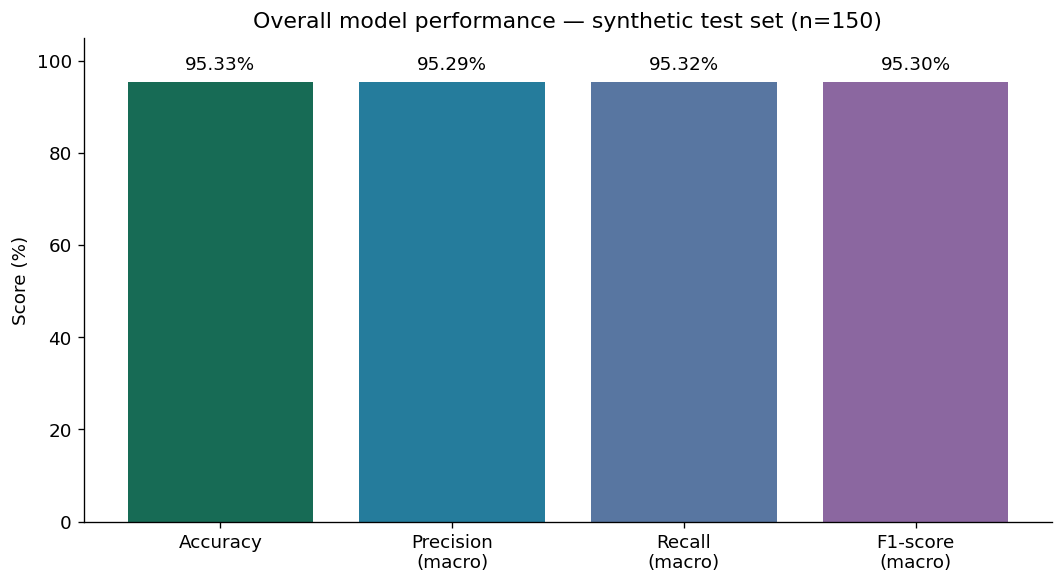

In [7]:
#@title 7. Overall performance graph — synthetic test set
plt.rcParams.update({"font.size":11,"figure.dpi":120})
FIGS=Path("reports/figures");FIGS.mkdir(exist_ok=True)
fig,ax=plt.subplots(figsize=(9,5))
values=[100*test[k] for k in ["accuracy","precision_macro","recall_macro","macro_f1"]]
bars=ax.bar(["Accuracy","Precision\n(macro)","Recall\n(macro)","F1-score\n(macro)"],values,color=["#176b55","#257c9c","#5876a1","#8b67a0"])
ax.bar_label(bars,labels=[f"{v:.2f}%" for v in values],padding=5)
ax.set(ylim=(0,105),ylabel="Score (%)",title="Overall model performance — synthetic test set (n=150)")
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout();fig.savefig(FIGS/"overall_performance.png",dpi=300,bbox_inches="tight");plt.show()

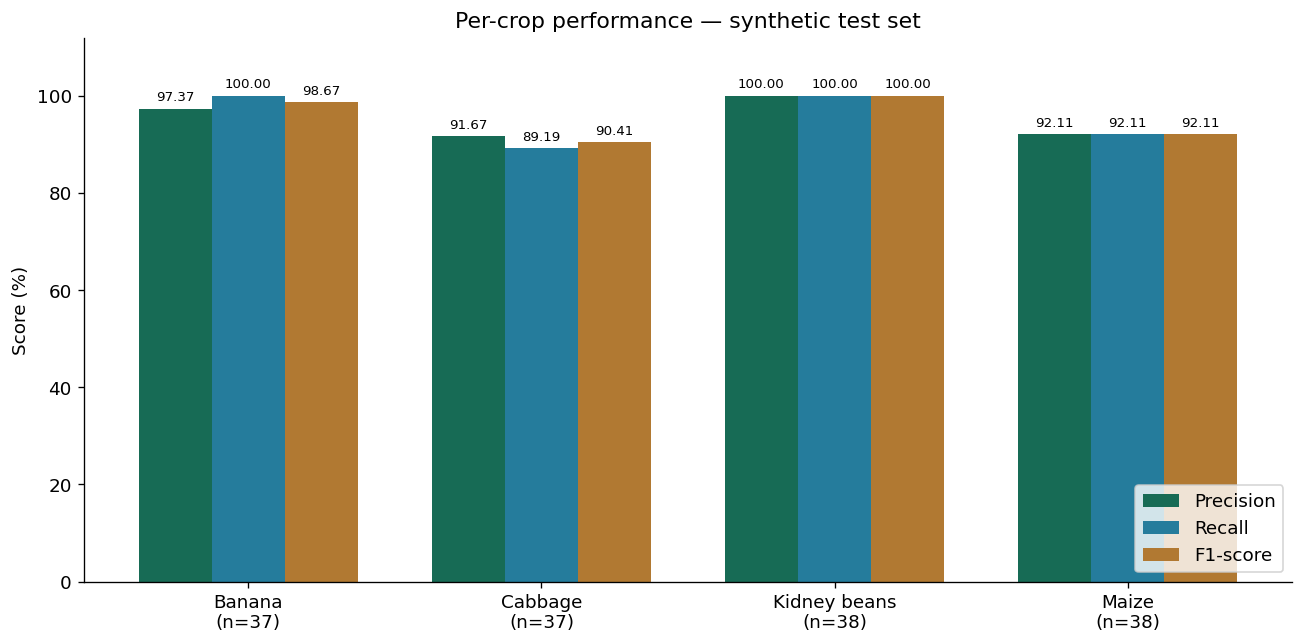

In [8]:
#@title 8. Per-crop classification performance graph
labels=test["labels"]
names=["Kidney beans" if v=="kidneybeans" else v.title() for v in labels]
report=test["classification_report"]
fig,ax=plt.subplots(figsize=(11,5.5));positions=np.arange(len(labels));width=.25
for offset,key,label,color in [(-1,"precision","Precision","#176b55"),(0,"recall","Recall","#257c9c"),(1,"f1-score","F1-score","#b17932")]:
    vals=[100*report[v][key] for v in labels]
    bars=ax.bar(positions+offset*width,vals,width,label=label,color=color)
    ax.bar_label(bars,labels=[f"{v:.2f}" for v in vals],padding=3,fontsize=8)
tick_labels=["%s\n(n=%d)" % (name,report[v]["support"]) for name,v in zip(names,labels)]
ax.set_xticks(positions,tick_labels)
ax.set(ylim=(0,112),ylabel="Score (%)",title="Per-crop performance — synthetic test set")
ax.legend(loc="lower right");ax.spines[["top","right"]].set_visible(False)
fig.tight_layout();fig.savefig(FIGS/"per_crop_performance.png",dpi=300,bbox_inches="tight");plt.show()

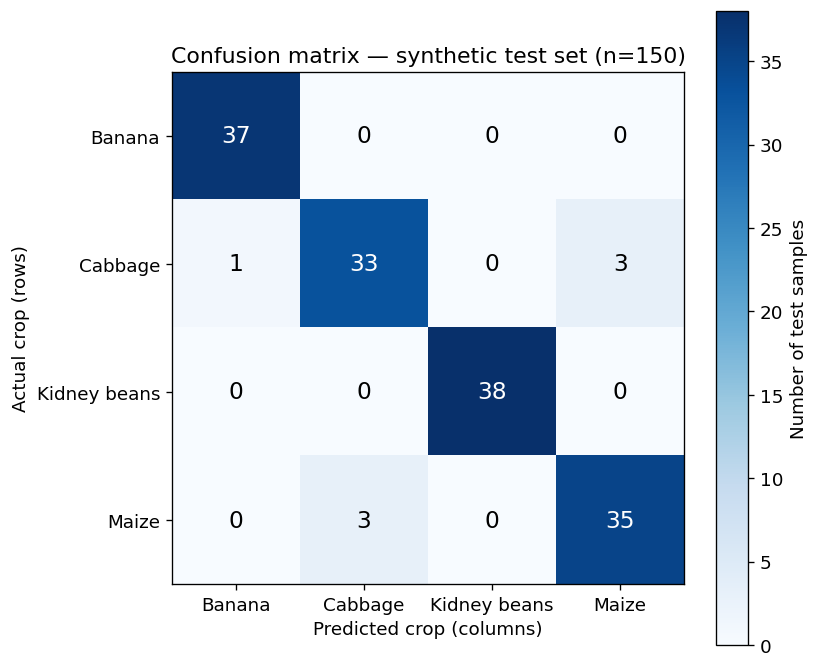

In [9]:
#@title 9. Confusion matrix — actual rows, predicted columns
cm=np.array(test["confusion_matrix"])
fig,ax=plt.subplots(figsize=(7,6))
img=ax.imshow(cm,cmap="Blues",vmin=0)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j,i,str(cm[i,j]),ha="center",va="center",fontsize=14,color="white" if cm[i,j]>cm.max()/2 else "black")
ax.set_xticks(range(4),names);ax.set_yticks(range(4),names)
ax.set(xlabel="Predicted crop (columns)",ylabel="Actual crop (rows)",title="Confusion matrix — synthetic test set (n=150)")
fig.colorbar(img,ax=ax,label="Number of test samples")
fig.tight_layout();fig.savefig(FIGS/"confusion_matrix.png",dpi=300,bbox_inches="tight");plt.show()

In [10]:
#@title 10. Missing and invalid readings — transparent provisional predictions
import importlib.util
from soil_ml.fusion import fuse_frame
spec=importlib.util.spec_from_file_location("edge_predict",REPO/"edge/predict.py")
edge=importlib.util.module_from_spec(spec);spec.loader.exec_module(edge)
edge.MODEL=model.to_dict(MODEL_FEATURES)
edge.META["medians"]=fuse_frame(x_train).median().tolist()
row=x_test.iloc[0]
order=["SM","ST7in1","pH","N","P","K","EC","STDS18B20","SMCap"]
raw=[float(row[k]) for k in order]
scenarios={"complete":raw.copy(),"missing N":raw.copy(),"invalid pH":raw.copy(),"all missing":[float("nan")]*9}
scenarios["missing N"][3]=float("nan");scenarios["invalid pH"][2]=99
for name,values in scenarios.items():
    result=edge.predict(values)
    print(name, json.dumps(result))
    assert result["crop"] in model.classes_
    if name!="complete": assert result["issues"] and result["substitutions"]
print("Missing/invalid inputs are disclosed; median substitutions use training data only.")
print("All-missing predictions are defaults, not evidence of crop suitability. Zero EC/NPK sensor values require physical validation.")

complete {"prototype": true, "status": "complete_inputs", "crop": "kidneybeans", "measured_features": 7, "required_features": 7, "issues": [], "substitutions": [], "moisture_source": "fused", "temperature_source": "fused", "field_validated": false}
missing N {"prototype": true, "status": "provisional", "crop": "maize", "measured_features": 6, "required_features": 7, "issues": [{"input": "N", "reason": "missing_or_nonfinite_or_marked_failed"}], "substitutions": [{"feature": "N", "method": "training_median", "value": 82.0555426159897}], "moisture_source": "fused", "temperature_source": "fused", "field_validated": false}
invalid pH {"prototype": true, "status": "provisional", "crop": "kidneybeans", "measured_features": 6, "required_features": 7, "issues": [{"input": "pH", "reason": "outside_prototype_range"}], "substitutions": [{"feature": "pH", "method": "training_median", "value": 6.278272677225246}], "moisture_source": "fused", "temperature_source": "fused", "field_validated": false}
a

In [11]:
#@title 11. Functional tests — generation, fusion, training and C export
result=subprocess.run([sys.executable,"-m","pytest","-q","tests"],capture_output=True,text=True)
print(result.stdout);print(result.stderr)
Path("reports/colab_functional_tests.txt").write_text(result.stdout+result.stderr)
assert result.returncode==0, "Functional tests failed; inspect output before accepting results."

..............                                                           [100%]
14 passed in 3.22s




In [12]:
#@title 12. ESP32 model export and reproduction commands
from soil_ml.export_c import export_model_header
export=export_model_header("models/soil_rf_desktop.json","reports/export/crop_model.h","reports/export/metadata.json")
print(export)
print("Run from the repository training directory, with PYTHONPATH=src:")
commands=["python -m soil_ml.cli synthetic --rows-per-crop 250 --seed 42", "python -m soil_ml.cli train", "python -m soil_ml.cli export", "python -m pytest -q tests"]
print("\n".join(commands))
Path("reports/reproduction_commands.txt").write_text("Source commit: "+COMMIT+"\nPYTHONPATH=src\n"+"\n".join(commands))
versions={"python":sys.version,"numpy":np.__version__,"pandas":pd.__version__}
Path("reports/colab_environment.json").write_text(json.dumps(versions,indent=2))
print("Runtime versions:",versions)
print("Export only: no physical board upload or hardware test was performed by this notebook.")

{'features': ['SMFused', 'STFused', 'pH', 'N', 'P', 'K', 'EC'], 'classes': ['banana', 'cabbage', 'kidneybeans', 'maize'], 'tree_count': 15, 'total_nodes': 555, 'artifact_type': 'ESP32-compatible C/C++ header', 'source_artifact': 'TinyRandomForest JSON (not sklearn joblib)', 'desktop_pickle_warning': '.joblib/.pkl artifacts are not used. ESP32 loads crop_model.h only.'}
Run from the repository training directory, with PYTHONPATH=src:
python -m soil_ml.cli synthetic --rows-per-crop 250 --seed 42
python -m soil_ml.cli train
python -m soil_ml.cli export
python -m pytest -q tests
Runtime versions: {'python': '3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]', 'numpy': '2.1.3', 'pandas': '2.2.3'}
Export only: no physical board upload or hardware test was performed by this notebook.
